In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Stat I project: FIFA World Cup 2026 player performance

**Dataset #7:** `fifa_world_cup_2026_player_performance.csv`

**Authors:** Macéo Drouot and Axel Bachon

## Loading the data

In [4]:
raw = pd.read_csv('statsbomb_world_cup_2022_player_match.csv') # reads the file
raw

,competition_id,season_id,match_id,match_date,match_name,stage,player_id,player_name,team_id,team_name,...,dribbles,completed_dribbles,pressures,tackles,interceptions,fouls_committed,fouls_won,total_pass_distance,total_carry_distance,expected_goals
0,43,106,3857286,2022-11-20,Qatar - Ecuador,Group Stage,12803,Romario Andrés Ibarra Mina,3565,Ecuador,...,1,1,8,0,0,0,0,170.148306,115.510117,0.136638
1,43,106,3857286,2022-11-20,Qatar - Ecuador,Group Stage,23830,Jhegson Sebastián Méndez Carabalí,3565,Ecuador,...,0,0,9,3,0,3,1,1566.175661,241.277374,0.000000
2,43,106,3857286,2022-11-20,Qatar - Ecuador,Group Stage,24085,Pervis Josué Estupiñán Tenorio,3565,Ecuador,...,1,1,7,3,1,3,0,1465.181417,243.689772,0.000000
3,43,106,3857286,2022-11-20,Qatar - Ecuador,Group Stage,28559,Enner Remberto Valencia Lastra,3565,Ecuador,...,3,2,14,0,0,1,4,264.577535,82.604804,0.872281
4,43,106,3857286,2022-11-20,Qatar - Ecuador,Group Stage,30111,Felix Eduardo Torres Caicedo,3565,Ecuador,...,1,0,4,0,1,0,0,1443.594843,231.100259,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1990,43,106,3869685,2022-12-18,Argentina - France,Final,7161,Germán Alejandro Pezzella,779,Argentina,...,0,0,0,0,0,0,0,18.220043,0.500000,0.000000
1991,43,106,3869685,2022-12-18,Argentina - France,Final,11456,Lautaro Javier Martínez,779,Argentina,...,0,0,2,0,0,0,0,62.932389,27.414423,0.583520
1992,43,106,3869685,2022-12-18,Argentina - France,Final,16308,Leandro Daniel Paredes,779,Argentina,...,0,0,5,1,0,1,0,281.049523,66.599847,0.000000
1993,43,106,3869685,2022-12-18,Argentina - France,Final,19597,Marcos Javier Acuña,779,Argentina,...,2,0,10,1,0,2,0,559.046995,139.699373,0.000000


In [5]:
raw.info() # data types and possible NaN values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1995 entries, 0 to 1994
Data columns (total 38 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   competition_id          1995 non-null   int64  
 1   season_id               1995 non-null   int64  
 2   match_id                1995 non-null   int64  
 3   match_date              1995 non-null   object 
 4   match_name              1995 non-null   object 
 5   stage                   1995 non-null   object 
 6   player_id               1995 non-null   int64  
 7   player_name             1995 non-null   object 
 8   team_id                 1995 non-null   int64  
 9   team_name               1995 non-null   object 
 10  opponent_id             1995 non-null   int64  
 11  opponent_name           1995 non-null   object 
 12  is_home                 1995 non-null   int64  
 13  position_id             1995 non-null   int64  
 14  position                1995 non-null   

The raw file has 54,600 rows and 75 columns, with no missing values. Each row is **one player in one match**. It gives:
- the player's profile: age, nationality, team, position, height, weight, club, market value;
- the match: date, stadium, opponent, stage, result;
- the player's statistics in that match: minutes, goals, shots, passes, distance, etc.;
- a few scores and tournament totals.

There are 1,050 matches and **52 rows per match**: the full squad of 26 players of each of the two teams is listed, including the substitutes who did not enter the pitch.

23,042 rows (about 42%) describe players who stayed on the bench: they have 0 minutes, 0 km, 0 shots, etc. These rows describe **no performance**. If we keep them, `distance_covered_km` gets an artificial peak at 0 that has nothing to do with the physical effort of a player. We therefore keep only the rows where the player actually played (`minutes_played > 0`).

In [6]:
df = raw[raw.minutes_played > 0].reset_index(drop=True) # keep only the players who played
n = len(df)
n

31558

# Template for describing data

## Population under study:

- **Population:** the appearances of players at the FIFA World Cup 2026, as recorded in the dataset. A unit is one player in one match where that player played at least one minute.
- **Number of observations:** 31,558 (54,600 rows in the raw file).
- **Time series (Y/N):** N. Each row has a match date, but the observations are not one quantity followed over time. They are many players observed in many matches.

In [7]:
df.nunique() # number of different levels/values of each variable

player_id                   1248
player_name                 1245
age                           23
nationality                   48
team                          48
                            ... 
total_goals_tournament        11
total_assists_tournament       9
total_minutes_tournament     574
player_of_match_awards         5
tournament_rating             62
Length: 75, dtype: int64

In [8]:
df[['shots', 'distance_covered_km', 'minutes_played']].describe() # range of the numerical variables

,shots,distance_covered_km,minutes_played
count,31558.000000,31558.000000,31558.000000
mean,0.773465,6.914541,62.631029
std,1.140028,2.797708,25.286945
min,0.000000,2.000000,5.000000
25%,0.000000,4.400000,40.000000
50%,0.000000,7.500000,72.000000
75%,1.000000,9.000000,82.000000
max,11.000000,14.000000,90.000000


## Variables:

The dataset has 75 variables. We describe the three we selected for the project, plus a few variables that help us understand the data.

| Name | Cat./Disc./Cont. | Obs./Exp. | levels, values or range |
|---|---|---|---|
| **`position`** | Categorical | Observed | 4 levels: Goalkeeper, Defender, Midfielder, Forward |
| **`shots`** | Numerical discrete | Observed | integers from 0 to 11 (shots in the match) |
| **`distance_covered_km`** | Numerical continuous | Observed | from 2 to 14 km (recorded to 0.1 km) |
| `minutes_played` | Numerical discrete | Observed | integers from 5 to 90 |
| `team` | Categorical | Observed | 48 national teams |
| `tournament_stage` | Categorical (ordinal) | Observed | 7 levels: Group Stage, Round of 32, Round of 16, Quarter Finals, Semi Finals, Third Place Match, Final |

**Selected variables:**
- `position` is categorical: it names a role on the pitch and has no order.
- `shots` is discrete: it is a count, with only 12 different values.
- `distance_covered_km` is continuous: it is a physical measurement. It is rounded to 0.1 km, but it can take any value in an interval.

## Source and quality:

- **source:** Kaggle, *FIFA World Cup 2026 Player Performance Dataset* (https://www.kaggle.com/datasets/rauffauzanrambe/fifa-world-cup-2026-player-performance-dataset), proposed in the course project list.
- **data collection method (census/sampling method):** census. The file claims to list every player of every match of the tournament.
- **quality/reliability:** the file is clean: no missing values, consistent types, 26 players per team and per match. Its **reliability is doubtful**, however, and the data looks **synthetic**:
  - it contains 1,050 matches, whereas the real 2026 World Cup (48 teams) has 104 matches;
  - many player names are invented or mixed (e.g. *Rodri Fati*, *Ansu Le Normand*), and some clubs are unlikely (*Gavi Ramos* at AIK);
  - every player who enters the pitch covers at least 2 km, even after only 5 minutes of play.

  We therefore study the data as a statistical exercise, and we do not draw conclusions about the real tournament.

## Raw/process (if not raw):

The data are processed:
- We removed the 23,042 rows with `minutes_played = 0` (unused substitutes), because they describe no performance. We keep 31,558 of the 54,600 rows.
- The values themselves are not modified.

## Frequency tables

### Categorical variable: `position`

In [9]:
values_pos, counts_pos = np.unique(df.position, return_counts=True)
table_pos = pd.DataFrame({'freq.': counts_pos}, index=values_pos)
table_pos.index.name = 'position'
table_pos['rel. freq.'] = counts_pos / n
table_pos

,freq.,rel. freq.
position,,
Defender,11484,0.363901
Forward,7700,0.243995
Goalkeeper,2100,0.066544
Midfielder,10274,0.325559


Defenders and midfielders make up most of the appearances. Goalkeepers are the least represented, because only one goalkeeper plays per team (2 per match). There is no cumulated frequency here, because the levels have no order.

### Discrete variable: `shots`

In [10]:
values_s, counts_s = np.unique(df.shots, return_counts=True) # the values are ordered
s = pd.Series(data=counts_s, index=values_s)
s.index.name = 'shots'
s.name = 'freq.'
table_s = s.to_frame()
table_s['rel. freq.'] = counts_s / n
table_s['cumul. rel. freq.'] = np.cumsum(table_s['rel. freq.'])
table_s

,freq.,rel. freq.,cumul. rel. freq.
shots,,,
0,17497,0.554439,0.554439
1,8084,0.256163,0.810603
2,3422,0.108435,0.919038
3,1484,0.047025,0.966062
4,623,0.019741,0.985804
5,263,0.008334,0.994138
6,108,0.003422,0.997560
7,53,0.001679,0.999239
8,18,0.000570,0.999810


More than half of the players (about 55%) do not shoot at all during a match, and about 81% shoot at most once. The frequencies decrease quickly: shooting 5 times or more is rare, and the maximum is 11 shots.

### Continuous variable: `distance_covered_km`

The values go from 2 to 14 km. We use 12 classes of 1 km. Each class contains at least 5 units, so we do not need to merge any classes.

In [11]:
counts_d, bins_d = np.histogram(df.distance_covered_km, bins=np.arange(2, 15, 1)) # classes [2,3), [3,4), ..., [13,14]
counts_d, bins_d

(array([3474, 3822, 1243, 1567, 3240, 4856, 5240, 4127, 2480, 1046,  352,
         111]),
 array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]))

In [12]:
intervals = pd.IntervalIndex.from_breaks(bins_d, closed='left')
intervals_list = list(intervals)
intervals_list[-1] = pd.Interval(bins_d[-2], bins_d[-1], closed='both') # last interval is closed
intervals = pd.Index(intervals_list)
table_d = pd.DataFrame({'freq.': counts_d}, index=intervals)
table_d.index.name = 'distance (km)'
table_d['rel. freq.'] = counts_d / n
table_d['cumul. rel. freq.'] = np.cumsum(table_d['rel. freq.'])
table_d

,freq.,rel. freq.,cumul. rel. freq.
distance (km),,,
"[2, 3)",3474,0.110083,0.110083
"[3, 4)",3822,0.121110,0.231193
"[4, 5)",1243,0.039388,0.270581
"[5, 6)",1567,0.049655,0.320236
"[6, 7)",3240,0.102668,0.422904
"[7, 8)",4856,0.153875,0.576779
"[8, 9)",5240,0.166043,0.742823
"[9, 10)",4127,0.130775,0.873598
"[10, 11)",2480,0.078585,0.952183


The distribution has **two groups**:
- short distances (2 to 4 km): mostly players who came on as substitutes;
- long distances (7 to 10 km): mostly players who played the whole match.

The graphics below show this more clearly.

## Graphical representations

### `position`: bar chart and pie chart

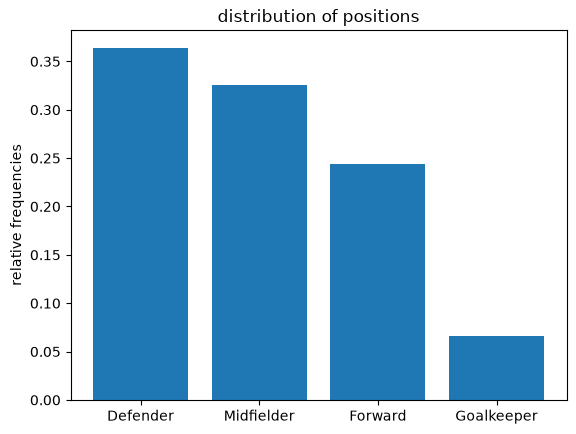

In [13]:
counts = df.position.value_counts()
plt.bar(counts.index, counts.values / n)
plt.ylabel('relative frequencies')
plt.title('distribution of positions')

plt.show()

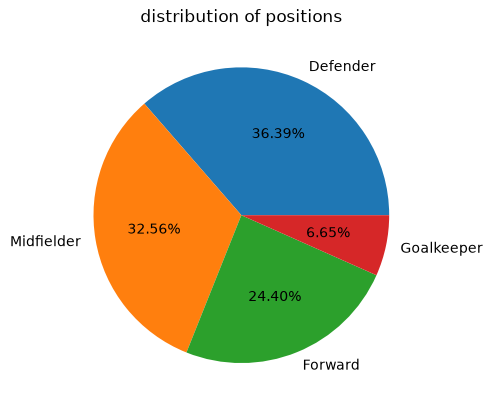

In [14]:
plt.pie(counts.values, labels=counts.index, autopct='%.2f%%') # always plots relative frequencies
plt.title('distribution of positions')

plt.show()

Both charts show the same ranking: Defender > Midfielder > Forward > Goalkeeper. The pie chart shows the proportions directly, and the bar chart makes the categories easier to compare.

### `shots`: bar chart and line plot

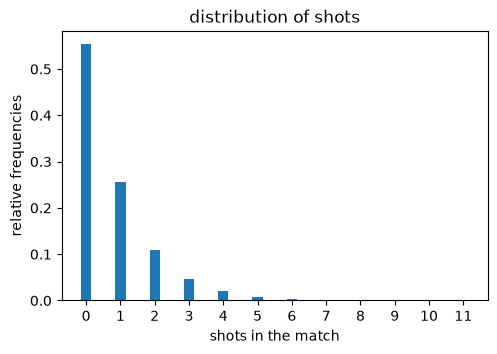

In [15]:
plt.figure(figsize=(5.5, 3.5))
plt.bar(values_s, counts_s / n, width=0.3)
plt.xticks(values_s, values_s) # horizontal axis coherent with the data
plt.xlabel('shots in the match')
plt.ylabel('relative frequencies')
plt.title('distribution of shots')

plt.show()

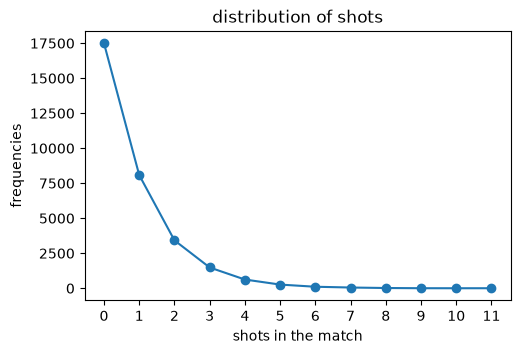

In [16]:
plt.figure(figsize=(5.5, 3.5))
plt.plot(values_s, counts_s, marker='o')
plt.xticks(values_s, values_s)
plt.xlabel('shots in the match')
plt.ylabel('frequencies')
plt.title('distribution of shots')

plt.show()

The distribution is strongly **right-skewed**. The mode is 0, and the frequency decreases fast as the number of shots increases. The line plot shows that the frequencies after 5 shots are almost zero.

### `distance_covered_km`: histogram and boxplot

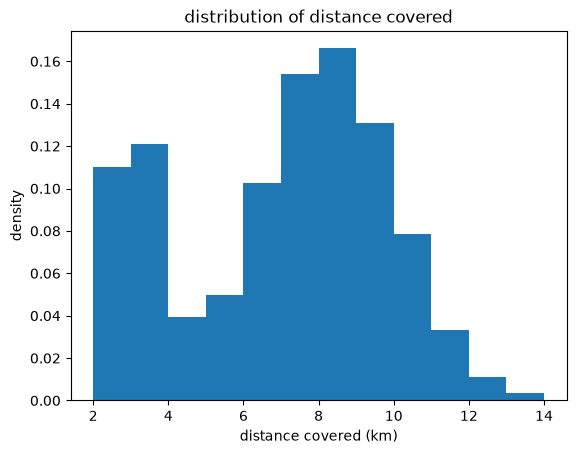

In [17]:
plt.hist(df.distance_covered_km, bins=bins_d, density=True) # histogram of relative frequencies (density)
plt.xlabel('distance covered (km)')
plt.ylabel('density')
plt.title('distribution of distance covered')

plt.show()

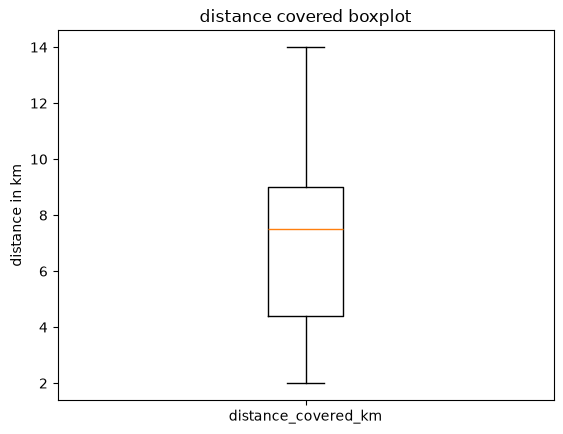

In [18]:
plt.boxplot(df.distance_covered_km) # quantiles are calculated with method = 'linear'
plt.xticks([1], ['distance_covered_km'])
plt.ylabel('distance in km')
plt.title('distance covered boxplot')

plt.show()

The histogram is **bimodal**: one peak around 2-4 km (short appearances) and one around 7-9 km (full matches). The boxplot hides this double shape. It shows a median around 7.5 km and a wide box, and no point outside the whiskers. This is why it is useful to look at both graphics.

## Outliers

We use the rule seen with the boxplot. A value is an outlier if it lies outside $[Q_1 - 1.5\,IQR,\; Q_3 + 1.5\,IQR]$, where $IQR = Q_3 - Q_1$. The quartiles are calculated with `method = 'inverted_cdf'`, as in the lecture.

In [19]:
alpha = [0., .25, .5, .75, 1.]
q_s = np.quantile(df.shots, alpha, method='inverted_cdf')
q_d = np.quantile(df.distance_covered_km, alpha, method='inverted_cdf')
q_s, q_d

(array([ 0,  0,  0,  1, 11]), array([ 2. ,  4.4,  7.5,  9. , 14. ]))

In [20]:
for name, q in [('shots', q_s), ('distance_covered_km', q_d)]:
    iqr = q[3] - q[1]
    low, high = q[1] - 1.5 * iqr, q[3] + 1.5 * iqr
    nb_out = ((df[name] < low) | (df[name] > high)).sum()
    print(name, ': fences =', (low, high), ', outliers =', nb_out, '(', round(100 * nb_out / n, 1), '% )')

shots : fences = (np.float64(-1.5), np.float64(2.5)) , outliers = 2555 ( 8.1 % )
distance_covered_km : fences = (np.float64(-2.499999999999999), np.float64(15.899999999999999)) , outliers = 0 ( 0.0 % )


**`distance_covered_km`:** there is no outlier. All distances lie between the fences, and the minimum (2 km) and the maximum (14 km) are realistic for a football match.

**`shots`:** $Q_1 = 0$ and $Q_3 = 1$, so the upper fence is $2.5$. Every player with **3 shots or more** counts as an outlier, which is about 8% of the observations. This many outliers is expected for a strongly skewed count. We check who these players are:

In [21]:
out_s = df[df.shots >= 3]
out_s.position.value_counts() / len(out_s) # positions of the players with 3 shots or more

position
Forward       0.728767
Midfielder    0.236791
Defender      0.034442
Name: count, dtype: float64

In [22]:
out_s.minutes_played.describe() # playing time of those players

count    2555.000000
mean       76.848532
std        13.505247
min        14.000000
25%        71.000000
50%        79.000000
75%        87.000000
max        90.000000
Name: minutes_played, dtype: float64

In [23]:
df.groupby('position').shots.mean() # mean number of shots per position

position
Defender      0.356496
Forward       1.610909
Goalkeeper    0.000000
Midfielder    0.770002
Name: shots, dtype: float64

**Interpretation:**
- Among the players with 3 shots or more, about 73% are **forwards**, 24% are midfielders and only 3% are defenders. Most of them played a large part of the match (median: 79 minutes).
- On average, a forward shoots about 1.6 times per match, a midfielder about 0.8 times, a defender about 0.4 times, and a goalkeeper never.
- These values are not measurement errors. They describe offensive players having a good match, which is what we expect in football.

**Decision:** we **keep** all the outliers. They are valid and meaningful observations of the population, and removing them would hide the most offensive performances. We simply keep in mind that the distribution of `shots` is very skewed. This will matter when we compute its moments (week 3).